In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from collections import Counter

sns.set_context("talk",rc={"font.size":15,"axes.titlesize":15,"axes.labelsize":15})
sns.set_style("whitegrid",{"grid.color": '.9', 'grid.linestyle': '--','axes.edgecolor': '.6', 'xtick.bottom': True,'ytick.left': True})

colorTable = {}
colorTable['k'] = [0,0,0]
colorTable['g'] = [27/255,158/255,119/255]
colorTable['o'] = [217/255,95/255,2/255]

import random

In [2]:
def prime(sequence):
    inverse_composite=sequence[::-1]
    for i in range(len(inverse_composite)):
        if inverse_composite[i]=='6':
            inverse_composite[i]='9'
        elif inverse_composite[i]=='9':
            inverse_composite[i]='6'
        elif inverse_composite[i].islower():
            inverse_composite[i]=inverse_composite[i].upper()
        elif inverse_composite[i].isupper():
            inverse_composite[i]=inverse_composite[i].lower()
        else:
            raise SyntaxError
    return inverse_composite

def detect_forward_sites(DNA,site):
    site_length = len(site)
    start_positions = []
    end_positions = []
    
    # Slide through the DNA looking for matches
    for i in range(len(DNA) - site_length + 1):
        # Check if current window matches the site
        if DNA[i:i+site_length] == site:
            start_positions.append(i)#computer positions
    
    return start_positions

def detect_backward_sites(DNA,site):
    site_length = len(site)
    start_positions = []
    end_positions = []
    
    # Slide through the DNA looking for matches
    for i in range(len(DNA) - site_length + 1):
        # Check if current window matches the site
        if DNA[i:i+site_length] == site[::-1]:
            start_positions.append(i)#computer positions
    
    return start_positions

#ALL positions recorded in natural counting, not computer indices, delete and inverts [site_1,site_2] inclusive
def delete_between(DNA,site_1,site_2):
    return DNA[:site_1-1]+DNA[site_2:]  

def invert_between(DNA,site_1,site_2):
    return DNA[:site_1-1]+prime(DNA[site_1-1:site_2])+DNA[site_2:] 

def evaluate_colour_CRE(DNA,choice1,choice2):

    num1, direction_1 = choice1
    num2, direction_2 = choice2
    #WLOG,make num 1 the smaller one
    if num1 > num2:
        num1, num2 = num2, num1
        direction_1, direction_2 = direction_2, direction_1
    
    # Determine which function to use
    if direction_1 == 'forward':
        if direction_1 == direction_2:
            return 'DoNotCount'#delete_between(DNA,num1+1,num2)
        elif direction_1!=direction_2:
            return invert_between(DNA,num1+1,num2+1)
    elif direction_1=='backward':
        if direction_1 == direction_2:
            return 'DoNotCount'#delete_between(DNA,num1+1,num2)
        else :
            return 'DoNotCount'
        

    

In [3]:
def evaluate_colour_CRE(DNA,choice1,choice2):

    num1, direction_1 = choice1
    num2, direction_2 = choice2
    #WLOG,make num 1 the smaller one
    if num1 > num2:
        num1, num2 = num2, num1
        direction_1, direction_2 = direction_2, direction_1
    
    # Determine which function to use
    if direction_1 == 'forward':
        if direction_1 == direction_2:
            return delete_between(DNA,num1+1,num2)
        elif direction_1!=direction_2:
            return invert_between(DNA,num1+1,num2+1)
    elif direction_1=='backward':
        if direction_1 == direction_2:
            return delete_between(DNA,num1+1,num2)
        else :
            return 'DoNotCount'

In [4]:
def probability_calculation(DNA):
    # Dictionary to store counts of each outcome
    outcome_list=[{DNA:1}]

    for _ in range(25):
        outcome_list.append({})
    recombinases_event=  0


    # Run simulations
    for stage in outcome_list:
        if recombinases_event<len(outcome_list)-1:
            recombinases_event+=1      
            for stored_result,probabilities in list(stage.items()):
                stored_result=list(stored_result)
                num_arrows=0
                forward_9_positions=detect_forward_sites(stored_result,['9'])
                backward_6_positions=detect_backward_sites(stored_result,['6'])
                # Randomly select two sites
                combined = [(num, 'forward') for num in forward_9_positions] + [(num, 'backward') for num in backward_6_positions]
                if len(combined)>=2:
                    for i in range(len(combined)):
                        for j in range(i+1,len(combined)):
                            num_arrows+=1

                    for i in range(len(combined)):
                        for j in range(i+1,len(combined)):
                            choice1,choice2 = combined[i], combined[j]
                            
                    
                            output = evaluate_colour_CRE(stored_result,choice1,choice2)
                            while output=='DoNotCount':
                                output=evaluate_colour_CRE(stored_result,choice1,choice2)
                            
                            if output!='DoNotCount':
                                formatted_output = "".join(output)
                                print(formatted_output)#!!!Remove before flight  
                                if formatted_output not in outcome_list[recombinases_event]:
                                    outcome_list[recombinases_event][formatted_output] = 0
                                    outcome_list[recombinases_event][formatted_output] += probabilities/num_arrows
                                else:    
                                    outcome_list[recombinases_event][formatted_output] += probabilities/num_arrows
        print('stage',recombinases_event,'completed')
    return outcome_list

In [5]:
initial_dna_sequence = "A9B6C9D6E9F6G9H6I"
numberofevents = 50
DNA = initial_dna_sequence

# outcome_lists= probability_calculation(initial_dna_sequence)

outcome_list=[]

for _ in range(numberofevents):
    outcome_list.append(Counter())
recombinases_event=  0

outcome_list[0][DNA] = 1

# Stage 1
for whichstage in range(1,numberofevents):
    stage = outcome_list[whichstage-1]
    for dna,probs in stage.items():
        # Now work out all the things the recombinases can do
        forward_9_positions=detect_forward_sites(list(dna),['9'])
        backward_6_positions=detect_backward_sites(list(dna),['6'])
        combined = [(num, 'forward') for num in forward_9_positions] + [(num, 'backward') for num in backward_6_positions]
        recombinase_acted = 0
        thisinput = Counter()
        for i in range(len(combined)):
            for j in range(i+1,len(combined)):
                choice1,choice2 = combined[i], combined[j]
                
                output = evaluate_colour_CRE(list(dna),choice1,choice2)

                if output!='DoNotCount':
                    recombinase_acted += 1
                    formatted_output = "".join(output)

                    # print(f"stage {whichstage} dna {dna} recombinase {recombinase_acted} output: {formatted_output}")  # !!!Remove before flight

                    thisinput[formatted_output] +=1

        if recombinase_acted==0:
            normfactor = 1
            thisinput[dna] = 1
        else:
            normfactor = recombinase_acted
        
        for key in thisinput:
            outcome_list[whichstage][key] += thisinput[key]*probs/normfactor


(0.0, 7.3855572735000585)

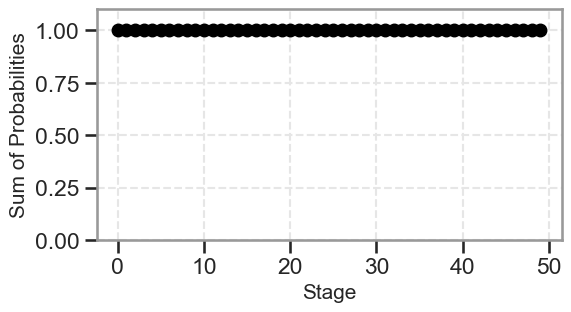

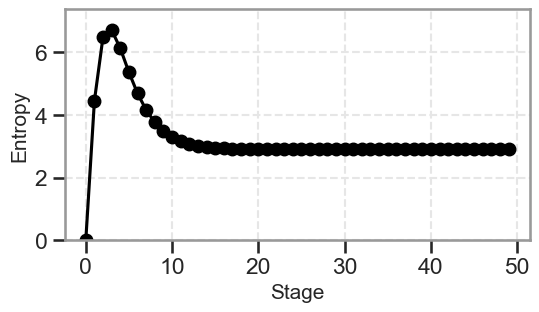

In [6]:
# Check to see if normalisation is preserved

probsum = np.zeros(numberofevents)
entropy = np.zeros(numberofevents)
for stage in range(numberofevents):
    probsum[stage] = np.sum(list(outcome_list[stage].values()))
    entropy[stage] = -np.sum([p * np.log2(p) for p in outcome_list[stage].values() if p > 0])


# Plot normalisation
plt.figure(figsize=(6, 3))
plt.plot(probsum, marker='o', linestyle='-', color='k')
plt.xlabel('Stage')
plt.ylabel('Sum of Probabilities')
plt.ylim(0, 1.1)

# Plot entropy
plt.figure(figsize=(6, 3))
plt.plot(entropy, marker='o', linestyle='-', color='k')
plt.xlabel('Stage')
plt.ylabel('Entropy')
plt.ylim(0, np.max(entropy) * 1.1)